

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Angel Joseph Vargas Martinez


# Introducción

### Señales sinusoidales discretas

Una señal sinusoidal discreta puede representarse como:

$$
x[n] = A\,\sin(\Omega n + \phi)
$$

donde:
- $A$ es la amplitud.
- $\Omega$ es la frecuencia discreta. 
- $\phi$ es la fase inicial.

En el caso de señales muestreadas, debemos relacionar la frecuencia analógica $f$ (en Hz) con la frecuencia discreta normalizada $\Omega$. La relación es:

$$
\Omega = 2\pi \frac{f}{F_s} \quad\text{o}\quad f = \frac{\Omega}{2\pi} F_s
$$

donde $F_s$ es la frecuencia de muestreo.  

Esto significa que la frecuencia de muestreo debe ser al menos el doble de la máxima frecuencia presente en la señal.


### Variables aleatorias y ruido

En el análisis de señales es muy común encontrarse con ruido, que modelamos mediante variables aleatorias. Dos ejemplos típicos son:

* Ruido uniforme:

$$
f_r \sim U(-2,2)
$$

Esto significa que el ruido puede tomar cualquier valor entre -2 y 2 con igual probabilidad.

* Ruido gaussiano (ruido blanco aditivo):

$$
n_a[n] \sim \mathcal{N}(0,\sigma^2)
$$

Es un ruido con distribución normal de media 0 y varianza $\sigma^2$.  
Se lo denomina blanco porque, en teoría, su energía está distribuida de manera uniforme en todas las frecuencias.


### Ventaneo

Cuando analizamos señales con la Transformada Discreta de Fourier (DFT), aparece un problema llamado leakage o desparramo espectral si la frecuencia de la señal no coincide con un múltiplo exacto de la resolución de la DFT.  

Para reducir este efecto se aplican ventanas, que son funciones que multiplican la señal en el tiempo antes de calcular la FFT.

Tipos de ventanas más utilizadas:

* Rectangular: equivale a no aplicar ventana. Tiene buena resolución en frecuencia pero mucho leakage.
* Flat-top: diseñada para estimar amplitudes con precisión, aunque pierde resolución en frecuencia.
* Blackman–Harris: ofrece un compromiso entre resolución (ancho del lóbulo principal) y atenuación de lóbulos laterales (reducción del leakage).

###  Estimadores: amplitud y frecuencia

En muchos casos necesitamos estimar parámetros de una señal a partir de muestras finitas y posiblemente ruidosas. Los más comunes son:

- Estimador de amplitud: intenta recuperar la amplitud real $a_0$ de la señal.
- Estimador de frecuencia: busca identificar la frecuencia dominante $f_0$ en el espectro.

Dos propiedades clave para evaluar un estimador $\hat{\theta}$ son:

* Sesgo (bias):

$$
s = E\{\hat{\theta}\} - \theta
$$

Mide si el valor promedio del estimador coincide o no con el valor verdadero $\theta$.

* Varianza:

$$
v = E\{(\hat{\theta} - E\{\hat{\theta}\})^2\}
$$

Mide la dispersión de los valores estimados alrededor de su media.

Un buen estimador es aquel que tiene bajo sesgo y baja varianza.

###  Estimación experimental del sesgo y la varianza

Supongamos que definimos un estimador de amplitud como:

$$
\hat{a}_0 = |X_w(\Omega_0)|
$$

donde $X_w(\Omega_0)$ es la DFT de la señal luego de aplicar una ventana $w$ y evaluar en la frecuencia $\Omega_0$.  

En teoría, las métricas del estimador son:

* Sesgo:

$$
s_a = E\{\hat{a}_0\} - a_0
$$

* Varianza:

$$
v_a = \operatorname{var}\{\hat{a}_0\} = E\{(\hat{a}_0 - E\{\hat{a}_0\})^2\}
$$

Sin embargo, en la práctica no conocemos el valor esperado $E\{\cdot\}$, y debemos aproximarlo mediante Monte Carlo: repetir el experimento $M$ veces, con diferentes realizaciones del ruido.

En este caso, las aproximaciones son:

* Media muestral del estimador:

$$
E\{\hat{a}_0\} \approx \mu_{\hat{a}} = \frac{1}{M} \sum_{j=0}^{M-1} \hat{a}_0^{(j)}
$$

* Sesgo aproximado:

$$
s_a \approx \mu_{\hat{a}} - a_0
$$

* Varianza aproximada:

$$
v_a \approx \frac{1}{M} \sum_{j=0}^{M-1} \left( \hat{a}_0^{(j)} - \mu_{\hat{a}} \right)^2
$$

Este procedimiento permite validar experimentalmente qué tan confiable es un estimador de amplitud o de frecuencia en condiciones ruidosas.



## Analsis y discusion

Defino las librerias, la señal con un SNR = 10 dB y tambien defino fr como una frecuencia que toma valores de -2 a 2 en una distribucion uniforme

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parámetros
N = 1000
fs = N
realizaciones = 200

snr_db = 10

a_0 = np.sqrt(2)
omega_0 = fs/4
df = fs/N

fr = np.random.uniform(-2, 2, realizaciones)
fr = np.reshape(fr, (1, realizaciones))

omega_1 = omega_0 + fr*df
f_1 = omega_1

tt = np.arange(0, N)/fs
tt = np.reshape(tt, (N,1))

s_1 = a_0*np.sin(2*np.pi*tt*f_1)

potencia_senal = a_0**2 / 2

sigma = np.sqrt(potencia_senal/(10**(snr_db/10)))

ruido = np.random.normal(0, sigma, (N, realizaciones))

x_1 = s_1 + ruido


Aca defino las ventanas y las aplico a la señal

In [29]:
# Ventanas

rectangular = np.ones(N)
gaussiana = signal.windows.gaussian(N, std=N/8)
blackman = signal.windows.blackmanharris(N)
flattop = signal.windows.flattop(N)

rectangular = np.reshape(rectangular, (N,1))
gaussiana  = np.reshape(gaussiana,  (N,1))
blackman   = np.reshape(blackman,   (N,1))
flattop    = np.reshape(flattop,    (N,1))

x_rect = x_1 * rectangular
x_gauss = x_1 * gaussiana
x_black = x_1 * blackman
x_flat  = x_1 * flattop


Realizo la FFT a las señales

In [30]:

XX_rect = np.fft.fft(x_rect, axis=0)/N
XX_gauss = np.fft.fft(x_gauss, axis=0)/N
XX_black = np.fft.fft(x_black, axis=0)/N
XX_flat  = np.fft.fft(x_flat, axis=0)/N

Calculo los estimadores de amplitud para cada señal, teniendo en cuenta que uso las frecuencias positivas, es decir el espectro unilateral

               | sa                    |va                  |
rectangular    | -0.9249427358286553   | 0.19989993178705728  |
gauss        | -1.103232633956526   | 0.00981326505372023  |
flattop        | -1.1356889619558515   | 0.001005796164524383 |
blackman harris| -1.0845923837858398  | 0.016864924968956006 |


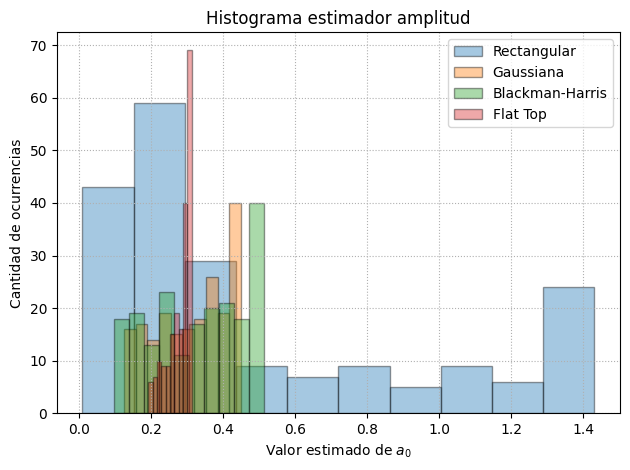

In [31]:
est_rect  = 2*np.abs(XX_rect[250,:])
var_rectangular=np.var(est_rect)
media_rectangular=np.mean(est_rect)-a_0

est_gauss = 2*np.abs(XX_gauss[250,:])
var_gauss=np.var(est_gauss)
media_gauss=np.mean(est_gauss)-a_0


est_black = 2*np.abs(XX_black[250,:])
var_bcharris=np.var(est_black)
media_bcharrix=np.mean(est_black)-a_0


est_flat  = 2*np.abs(XX_flat[250,:])
var_flatop=np.var(est_flat)
media_flatop=np.mean(est_flat)-a_0


plt.hist(est_rect,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Rectangular')

plt.hist(est_gauss,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Gaussiana')

plt.hist(est_black,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Blackman-Harris')

plt.hist(est_flat,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Flat Top')

plt.grid(True, linestyle=':')
plt.xlabel('Valor estimado de $a_0$')
plt.ylabel('Cantidad de ocurrencias')
plt.title('Histograma estimador amplitud')
plt.legend()
plt.tight_layout()




print('               | sa                    |va                  |')
print("rectangular    |",media_rectangular,"  |",var_rectangular," |",)
print("gauss        |",media_gauss,"  |",var_gauss," |",)
print("flattop        |",media_flatop,"  |",var_flatop,"|",)
print("blackman harris|",media_bcharrix," |",var_bcharris,"|",)


La ventana rectangular presenta una mayor dispersión y un comportamiento más sensible al leakage espectral. Esto ocurre porque la señal no coincide exactamente con un bin de la FFT debido a la perturbación aleatoria introducida por $f_r$. Como consecuencia, parte de la energía se reparte entre bins vecinos y el estimador de amplitud pierde precisión, presenta el menor sesgo y la mayor varianza

La ventana Flat-top presenta el mayor sesgo, aunque su varianza es extremadamente baja, indicamdo que las estimaciones son muy consistentes entre realizaciones, aunque desplazadas respecto al valor verdadero.

Las ventanas Gausiana y Blackman-Harris presentan un comportamiento intermedio, reduciendo considerablemente la varianza respecto a la rectangular


Acá calculo los estimadores de frecuencia

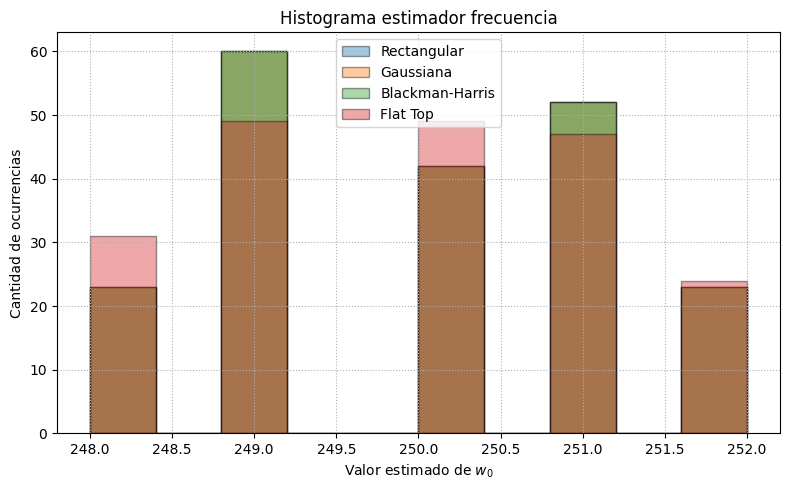

               | sa                    |va                  |
rectangular    | -0.03999999999999204   | 1.4784000000000004  |
gauss        | -0.03999999999999204   | 1.4784000000000004  |
flattop        | -0.0800000000000125   | 1.5736000000000003 |
blackman harris| -0.03999999999999204  | 1.4784000000000004 |


In [32]:

XX_rect_abs  = np.abs(XX_rect[:N//2+1,:])
XX_gauss_abs = np.abs(XX_gauss[:N//2+1,:])
XX_black_abs = np.abs(XX_black[:N//2+1,:])
XX_flat_abs  = np.abs(XX_flat[:N//2+1,:])

freq_rect  = np.argmax(XX_rect_abs, axis=0)
var_rectangular=np.var(freq_rect)
media_rectangular=np.mean(freq_rect)-omega_0


freq_gauss = np.argmax(XX_gauss_abs, axis=0)
var_gauss=np.var(freq_gauss)
media_gauss=np.mean(freq_gauss)-omega_0


freq_black = np.argmax(XX_black_abs, axis=0)
var_bcharris=np.var(freq_black)
media_bcharrix=np.mean(freq_black)-omega_0


freq_flat  = np.argmax(XX_flat_abs, axis=0)
var_flatop=np.var(freq_flat)
media_flatop=np.mean(freq_flat)-omega_0


plt.figure(figsize=(8,5))

plt.hist(freq_rect,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Rectangular')

plt.hist(freq_gauss,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Gaussiana')

plt.hist(freq_black,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Blackman-Harris')

plt.hist(freq_flat,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Flat Top')

plt.grid(True, linestyle=':')
plt.xlabel('Valor estimado de $w_0$')
plt.ylabel('Cantidad de ocurrencias')
plt.title('Histograma estimador frecuencia')
plt.legend()
plt.tight_layout()

plt.show()

print('               | sa                    |va                  |')
print("rectangular    |",media_rectangular,"  |",var_rectangular," |",)
print("gauss        |",media_gauss,"  |",var_gauss," |",)
print("flattop        |",media_flatop,"  |",var_flatop,"|",)
print("blackman harris|",media_bcharrix," |",var_bcharris,"|",)


Como el ruido todavía no domina sobre la señal para un SNR de 10 dB, la mayoría de las realizaciones identifican correctamente la frecuencia principal, los resultados obtenidos para el estimador de frecuencia muestran que todas las ventanas presentan un sesgo pequeño 
Para las ventanas rectangular, gaussiana y Blackman-Harris se obtuvo exactamente el mismo comportamiento. Esto muestra que las tres ventanas poseen prácticamente el mismo desempeño para este experimento en particular, la dispersión del estimador es moderada y la frecuencia dominante logra identificarse correctamente en la mayoría de las realizaciones.

La ventana Flat-top presenta el mayor sesgo yla mayor varianza, esto se debe a que la ventana Flat-top posee un lóbulo principal considerablemente más ancho que el resto, como consecuencia, disminuye la resolución espectral y empeora la localización precisa del máximo espectral.

Por ultimo calculo devuelta para un SNR= 3db

               | sa                    |va                  |
rectangular    | -0.9491863184504936   | 0.19621200197704858  |
hamming        | -1.1121739501033954   | 0.009486023968823405  |
flattop        | -1.1373566144055274   | 0.0009528417619146698 |
blackman harris| -1.0966647497038136  | 0.01635427647738974 |


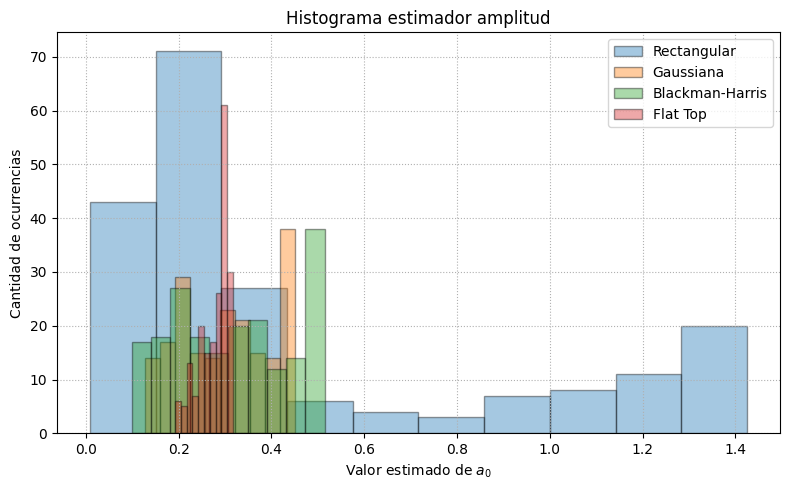

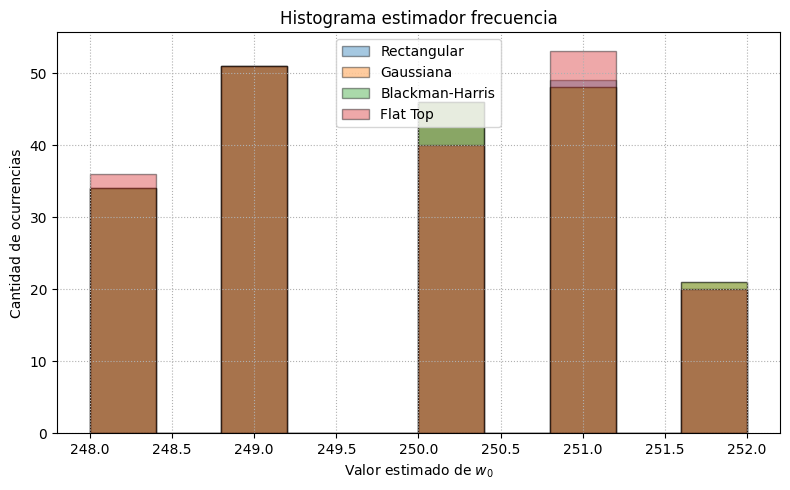

               | sa                    |va                  |
rectangular    | -0.15000000000000568   | 1.5574999999999997  |
hamming        | -0.14500000000001023   | 1.573975  |
flattop        | -0.15000000000000568   | 1.6174999999999997 |
blackman harris| -0.14500000000001023  | 1.573975 |


In [33]:
N = 1000
fs = N
realizaciones = 200

snr_db = 10

a_0 = np.sqrt(2)
omega_0 = fs/4
df = fs/N

fr = np.random.uniform(-2, 2, realizaciones)
fr = np.reshape(fr, (1, realizaciones))

omega_1 = omega_0 + fr*df
f_1 = omega_1

tt = np.arange(0, N)/fs
tt = np.reshape(tt, (N,1))

s_1 = a_0*np.sin(2*np.pi*tt*f_1)

potencia_senal = a_0**2 / 2

sigma = np.sqrt(potencia_senal/(10**(snr_db/10)))

ruido = np.random.normal(0, sigma, (N, realizaciones))

x_1 = s_1 + ruido


rectangular = np.ones(N)
gaussiana = signal.windows.gaussian(N, std=N/8)
blackman = signal.windows.blackmanharris(N)
flattop = signal.windows.flattop(N)

rectangular = np.reshape(rectangular, (N,1))
gaussiana  = np.reshape(gaussiana,  (N,1))
blackman   = np.reshape(blackman,   (N,1))
flattop    = np.reshape(flattop,    (N,1))


x_rect = x_1 * rectangular
x_gauss = x_1 * gaussiana
x_black = x_1 * blackman
x_flat  = x_1 * flattop

XX_rect = np.fft.fft(x_rect, axis=0)/N
XX_gauss = np.fft.fft(x_gauss, axis=0)/N
XX_black = np.fft.fft(x_black, axis=0)/N
XX_flat  = np.fft.fft(x_flat, axis=0)/N

est_rect  = 2*np.abs(XX_rect[250,:])
var_rectangular=np.var(est_rect)
media_rectangular=np.mean(est_rect)-a_0

est_gauss = 2*np.abs(XX_gauss[250,:])
var_gauss=np.var(est_gauss)
media_gauss=np.mean(est_gauss)-a_0


est_black = 2*np.abs(XX_black[250,:])
var_bcharris=np.var(est_black)
media_bcharrix=np.mean(est_black)-a_0


est_flat  = 2*np.abs(XX_flat[250,:])
var_flatop=np.var(est_flat)
media_flatop=np.mean(est_flat)-a_0

plt.figure(figsize=(8,5))

plt.hist(est_rect,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Rectangular')

plt.hist(est_gauss,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Gaussiana')

plt.hist(est_black,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Blackman-Harris')

plt.hist(est_flat,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Flat Top')

plt.grid(True, linestyle=':')
plt.xlabel('Valor estimado de $a_0$')
plt.ylabel('Cantidad de ocurrencias')
plt.title('Histograma estimador amplitud')
plt.legend()
plt.tight_layout()

print('               | sa                    |va                  |')
print("rectangular    |",media_rectangular,"  |",var_rectangular," |",)
print("hamming        |",media_gauss,"  |",var_gauss," |",)
print("flattop        |",media_flatop,"  |",var_flatop,"|",)
print("blackman harris|",media_bcharrix," |",var_bcharris,"|",)

XX_rect_abs  = np.abs(XX_rect[:N//2+1,:])
XX_gauss_abs = np.abs(XX_gauss[:N//2+1,:])
XX_black_abs = np.abs(XX_black[:N//2+1,:])
XX_flat_abs  = np.abs(XX_flat[:N//2+1,:])


freq_rect  = np.argmax(XX_rect_abs, axis=0)
var_rectangular=np.var(freq_rect)
media_rectangular=np.mean(freq_rect)-omega_0


freq_gauss = np.argmax(XX_gauss_abs, axis=0)
var_gauss=np.var(freq_gauss)
media_gauss=np.mean(freq_gauss)-omega_0


freq_black = np.argmax(XX_black_abs, axis=0)
var_bcharris=np.var(freq_black)
media_bcharrix=np.mean(freq_black)-omega_0


freq_flat  = np.argmax(XX_flat_abs, axis=0)
var_flatop=np.var(freq_flat)
media_flatop=np.mean(freq_flat)-omega_0


plt.figure(figsize=(8,5))

plt.hist(freq_rect,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Rectangular')

plt.hist(freq_gauss,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Gaussiana')

plt.hist(freq_black,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Blackman-Harris')

plt.hist(freq_flat,
         bins=10,
         alpha=0.4,
         edgecolor='black',
         label='Flat Top')

plt.grid(True, linestyle=':')
plt.xlabel('Valor estimado de $w_0$')
plt.ylabel('Cantidad de ocurrencias')
plt.title('Histograma estimador frecuencia')
plt.legend()
plt.tight_layout()

plt.show()

print('               | sa                    |va                  |')
print("rectangular    |",media_rectangular,"  |",var_rectangular," |",)
print("hamming        |",media_gauss,"  |",var_gauss," |",)
print("flattop        |",media_flatop,"  |",var_flatop,"|",)
print("blackman harris|",media_bcharrix," |",var_bcharris,"|",)


Al comparar los histogramas del estimador de amplitud para 10 dB y 3 dB, se observa que la forma general de las distribuciones se mantiene prácticamente igual.

Los valores de sesgo y varianza cambian muy poco entre ambos casos como con la ventana Rectangular

$$
v_a(10dB) \approx 0.190
$$

$$
v_a(3dB) \approx 0.196
$$

 y la Flat-top:

$$
v_a(10dB) \approx 0.00121
$$

$$
v_a(3dB) \approx 0.00095
$$

Esto indica que el comportamiento del estimador de amplitud está dominado principalmente por el efecto de la ventana y el leakage espectral, más que por el aumento del ruido.Por lo tanto, la reducción del SNR desde 10 dB hasta 3 dB no modifica significativamente el comportamiento relativo de los histogramas de amplitud.





Pero en el caso del estimador de frecuencia sí aparecen diferencias más visibles al reducir el SNR.
Las varianzas aumentan respecto al caso anterior, por ejemeplo la ventana rectangular 

$$
v_f(10dB) \approx 1.478
$$

$$
v_f(3dB) \approx 1.558
$$

y la Flat-top

$$
v_f(10dB) \approx 1.574
$$

$$
v_f(3dB) \approx 1.617
$$
Esto indica que el ruido afecta directamente la detección del máximo espectral, provocando mayor incertidumbre en la estimación de frecuencia.

También se observa que los sesgos negativos aumentan en magnitud como sucede en la ventana Rectangular:

$$
s_f(10dB) \approx -0.04
$$

$$
s_f(3dB) \approx -0.15
$$

Por lo tanto, con menor SNR la frecuencia estimada tiende a desplazarse aún más respecto al valor real.


# Conclusión 

A partir de los resultados obtenidos puede observarse claramente cómo la elección de la ventana y el nivel de ruido afectan el desempeño de los estimadores espectrales.

En el caso del estimador de amplitud, las ventanas suavizadas como Gaussiana, Blackman-Harris y especialmente Flat-top logran reducir significativamente la varianza respecto a la ventana rectangular.
La ventana rectangular, aunque posee menor sesgo en amplitud, presenta una dispersión considerablemente mayor debido al leakage espectral producido por la desintonía de la señal respecto a los bins de la FFT.

Mientras que paara el estimador de frecuencia, las diferencias entre ventanas son menores, las ventanas rectangular, gaussiana y Blackman-Harris muestran desempeños similares, mientras que la Flat-top presenta peor resolución frecauencial debido al ensanchamiento de su lóbulo principal.

Al disminuir el SNR desde 10 dB hasta 3 dB, el efecto más importante aparece sobre la estimación de frecuencia, donde aumentan tanto el sesgo como la varianza, esto evidenciia que el ruido dificulta la correcta detección del máximo espectral. En cambio, el estimador de amplitud mantiene un comportamiento relativamente estable, indicando que en este experimento domina principalmente el efecto de la ventana y del leakage espectral.
